# Level 2 · Task 1 — Logistic Regression for Binary Classification

**Goal:** predict whether a telecom customer will **churn** (leave) or not.

The dataset comes conveniently pre-split:
- `churn-bigml-80.csv` → training
- `churn-bigml-20.csv` → held-out test

**Steps:**
1. Load & explore
2. Preprocess (encode categoricals, handle collinearity, scale)
3. Train `LogisticRegression` and interpret coefficients / **odds ratios**
4. Evaluate — accuracy, precision, recall, **ROC curve**

*Tools: Python, pandas, scikit-learn, matplotlib*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

train = pd.read_csv('../data/churn-bigml-80.csv')
test = pd.read_csv('../data/churn-bigml-20.csv')
print('train:', train.shape, '  test:', test.shape)
train.head()

train: (2666, 20)   test: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
# sanity check
print(train.dtypes.value_counts())
print('\nmissing values:', train.isna().sum().sum())
print('\ntarget values:', train['Churn'].unique())

int64      8
float64    8
object     3
bool       1
Name: count, dtype: int64

missing values: 0

target values: [False  True]


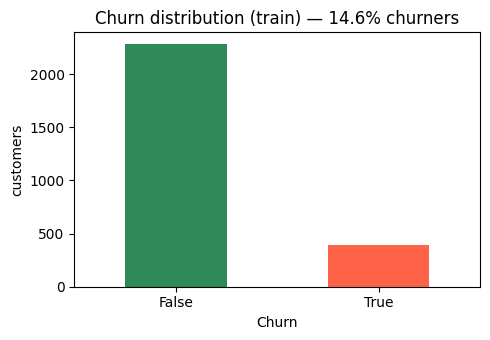

Churn
False    85.39999999999999%
True                  14.6%
Name: proportion, dtype: object


In [3]:
# how imbalanced is the target?
counts = train['Churn'].value_counts()
share = train['Churn'].value_counts(normalize=True).round(3) * 100

plt.figure(figsize=(5, 3.5))
counts.plot(kind='bar', color=['seagreen', 'tomato'])
plt.title(f'Churn distribution (train) — {share[True]:.1f}% churners')
plt.ylabel('customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(share.astype(str) + '%')